<a href="https://colab.research.google.com/github/SayooJSimon/Labs/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [103]:
data = pd.read_csv('adult.csv')
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [104]:
data.isin(['?']).sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [105]:
data.replace('?', np.nan)
data.dropna()
data.drop(['fnlwgt', 'educational-num', 'marital-status', 'relationship', 'race', 'native-country'], axis=1)

,age,workclass,education,occupation,gender,capital-gain,capital-loss,hours-per-week,income
0,25,Private,11th,Machine-op-inspct,Male,0,0,40,<=50K
1,38,Private,HS-grad,Farming-fishing,Male,0,0,50,<=50K
2,28,Local-gov,Assoc-acdm,Protective-serv,Male,0,0,40,>50K
3,44,Private,Some-college,Machine-op-inspct,Male,7688,0,40,>50K
4,18,?,Some-college,?,Female,0,0,30,<=50K
...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,Tech-support,Female,0,0,38,<=50K
48838,40,Private,HS-grad,Machine-op-inspct,Male,0,0,40,>50K
48839,58,Private,HS-grad,Adm-clerical,Female,0,0,40,<=50K
48840,22,Private,HS-grad,Adm-clerical,Male,0,0,20,<=50K


In [106]:
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(data['income'])
X = data.drop(['income'], axis=1)
X = pd.get_dummies(X)
X.head()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,18,103497,10,0,0,30,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [107]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy of the model is ', model.score(X_test, y_test))

Accuracy of the model is  0.8514689323369843


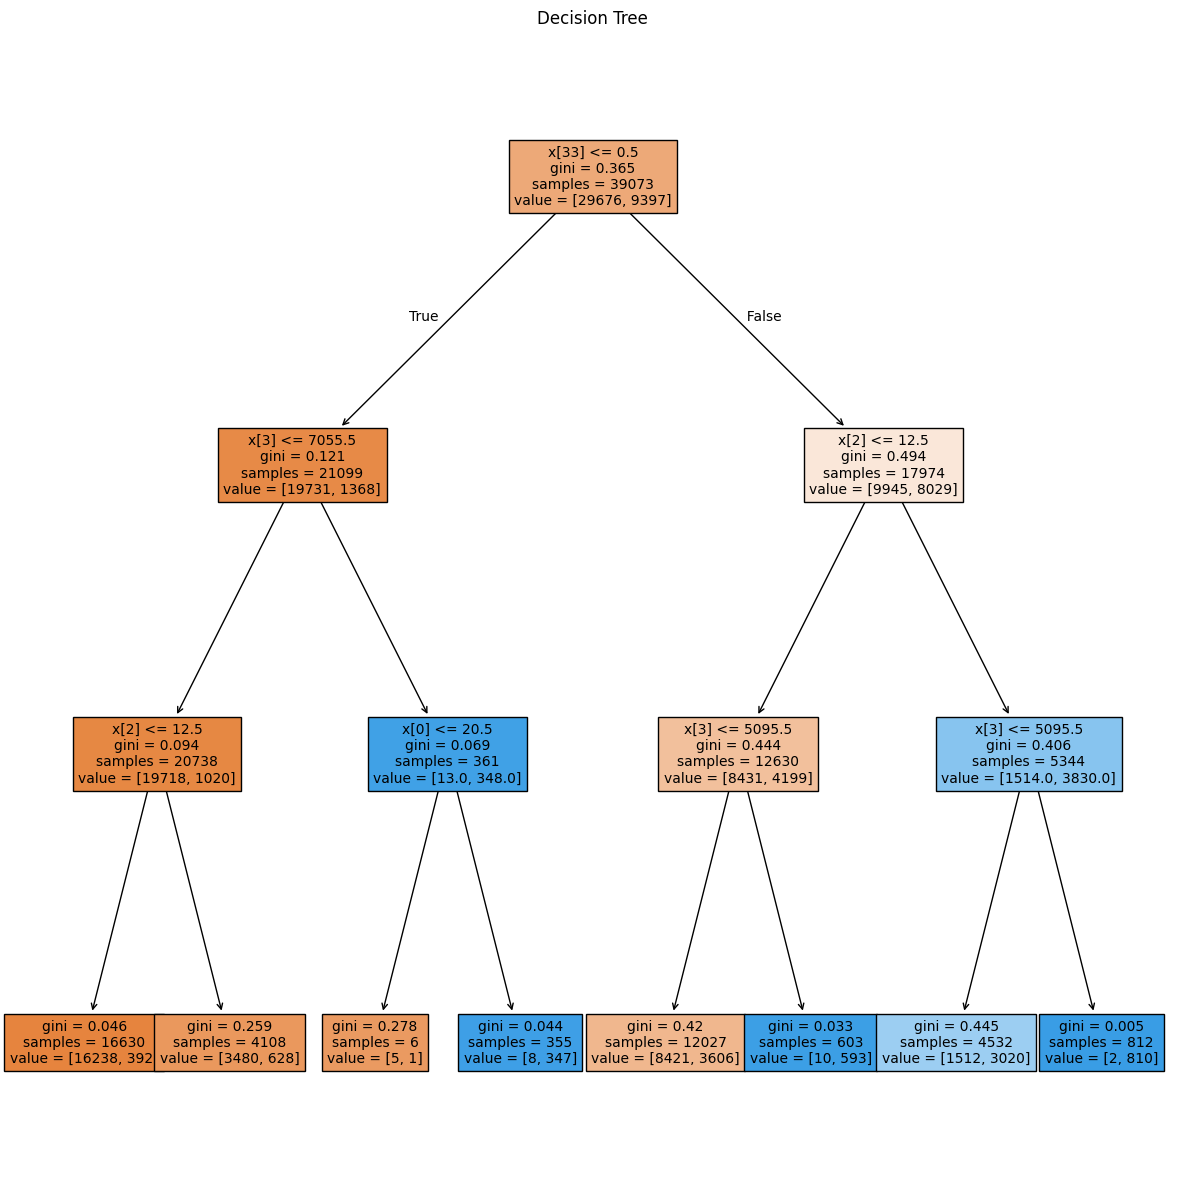

In [114]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,15))
plot_tree(model, fontsize=10, filled=True)
plt.title('Decision Tree')
plt.show()